In [1]:
import torch
from torch import nn
from torch.nn import functional as F

class VectorQuantizer(nn.Module):
    """
    Implements the core vector quantization layer of VQ-VAE.
    Each latent vector is replaced with its nearest embedding in a learned codebook.
    """

    def __init__(self, num_embeddings: int, embedding_dim: int, beta: float = 0.25):
        """
        Args:
            num_embeddings: Number of discrete codebook vectors (K)
            embedding_dim: Dimensionality of each embedding vector (D)
            beta: Weight for commitment loss
        """
        super(VectorQuantizer, self).__init__()
        self.K = num_embeddings  # size of codebook
        self.D = embedding_dim   # dimensionality of embedding vectors
        self.beta = beta         # commitment loss weight

        # Learnable embedding weights (the codebook)
        self.embedding = nn.Embedding(self.K, self.D)
        self.embedding.weight.data.uniform_(-1 / self.K, 1 / self.K)  # init

    def forward(self, latents: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass of VQ:
        - Quantizes the latents by finding the closest codebook vector
        - Computes the VQ loss
        - Uses straight-through estimator to pass gradients

        Args:
            latents: Tensor of shape [B, D, H, W]

        Returns:
            quantized_latents: Tensor [B, D, H, W]
            vq_loss: quantization + commitment loss
        """

        # 1️⃣ Change shape to [B, H, W, D] for easier processing
        latents = latents.permute(0, 2, 3, 1).contiguous() # [B x D x H x W] -> [B x H x W x D]
        latents_shape = latents.shape
        flat_latents = latents.view(-1, self.D)  # [BHW, D]

        # 2️⃣ Compute distances to all codebook embeddings [BHW x K]
        dist = (
            torch.sum(flat_latents ** 2, dim=1, keepdim=True) +  # ||z||^2
            torch.sum(self.embedding.weight ** 2, dim=1) -       # ||e||^2
            2 * torch.matmul(flat_latents, self.embedding.weight.t())  # -2·zᵀe
        )

        # 3️⃣ Find nearest embedding (argmin distance)
        encoding_inds = torch.argmin(dist, dim=1).unsqueeze(1)  # [BHW, 1]

        # 4️⃣ One-hot encode indices to get [BHW x K]
        device = latents.device
        encoding_one_hot = torch.zeros(encoding_inds.size(0), self.K, device=device)
        encoding_one_hot.scatter_(1, encoding_inds, 1)

        # 5️⃣ Quantize latents using codebook lookup
        quantized = torch.matmul(encoding_one_hot, self.embedding.weight)  # [BHW, D]
        quantized = quantized.view(latents_shape)  # [B, H, W, D]

        # 6️⃣ Compute VQ Losses
        commitment_loss = F.mse_loss(quantized.detach(), latents)
        embedding_loss = F.mse_loss(quantized, latents.detach())
        vq_loss = commitment_loss * self.beta + embedding_loss

        # 7️⃣ Straight-through estimator: allow gradients to pass through quantized
        quantized = latents + (quantized - latents).detach()

        # 8️⃣ Return to [B, D, H, W]
        return quantized.permute(0, 3, 1, 2).contiguous(), vq_loss


class ResidualLayer(nn.Module):
    """
    A simple residual block used in encoder/decoder.
    It learns a residual transformation: output = x + f(x)
    """

    def __init__(self, channels: int):
        """
        Args:
            channels: Number of input and output channels
        """
        super(ResidualLayer, self).__init__()

        self.block = nn.Sequential(
            nn.ReLU(True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(True),
            nn.Conv2d(channels, channels, kernel_size=1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Applies the residual block: output = x + block(x)
        """
        return x + self.block(x)

class VQVAE(nn.Module):
    """
    VQ-VAE full architecture: Encoder → Quantizer → Decoder
    """

    def __init__(self, in_channels=3, hidden_channels=128, embedding_dim=64, num_embeddings=512, commitment_cost=0.25):
        """
        Args:
            in_channels: Input image channels (3 for RGB)
            hidden_channels: Base number of channels for conv layers
            embedding_dim: Dimensionality of latent vectors (D)
            num_embeddings: Number of codebook embeddings (K)
            commitment_cost: β term for commitment loss
        """
        super(VQVAE, self).__init__()

        # 🔧 Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels // 2, kernel_size=4, stride=2, padding=1),  # 64 → 32
            nn.ReLU(),
            nn.Conv2d(hidden_channels // 2, hidden_channels, kernel_size=4, stride=2, padding=1),  # 32 → 16
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels, kernel_size=3, stride=1, padding=1),
            ResidualLayer(hidden_channels),
            ResidualLayer(hidden_channels)
        )

        # 🎯 Vector Quantizer Layer
        self.vq_layer = VectorQuantizer(num_embeddings, embedding_dim, beta=commitment_cost)

        # 🔁 Map encoder output to embedding space
        self.conv_to_embedding = nn.Conv2d(hidden_channels, embedding_dim, kernel_size=1)

        # 🔁 Map embedding space back to decoder input
        self.embedding_to_decoder = nn.Conv2d(embedding_dim, hidden_channels, kernel_size=1)

        # 🔧 Decoder
        self.decoder = nn.Sequential(
            ResidualLayer(hidden_channels),
            ResidualLayer(hidden_channels),
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, hidden_channels // 2, kernel_size=4, stride=2, padding=1),  # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels // 2, in_channels, kernel_size=4, stride=2, padding=1),  # 32 → 64
            nn.Tanh()  # Output in [-1, 1]
        )

    def encode(self, x):
        z = self.encoder(x)
        z = self.conv_to_embedding(z)
        return z

    def decode(self, quantized_z):
        z = self.embedding_to_decoder(quantized_z)
        x_recon = self.decoder(z)
        return x_recon

    def forward(self, x):
        """
        Full forward pass: x → encoder → quantizer → decoder → x_hat
        Returns:
            x_recon: reconstructed image
            vq_loss: quantization loss
        """
        z_e = self.encode(x)                      # Continuous latent
        z_q, vq_loss = self.vq_layer(z_e)         # Quantized latent
        x_recon = self.decode(z_q)                # Decode quantized representation
        return x_recon, vq_loss


In [2]:
model = VQVAE()  # or pass other args like VQVAE(in_channels=3, ...)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔢 Total parameters: {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")


🔢 Total parameters: 1,121,859
🎯 Trainable parameters: 1,121,859


In [3]:
def vqvae_loss_function(recon_x, x, vq_loss):
    """
    Total loss = Reconstruction loss + VQ loss

    Args:
        recon_x: reconstructed image
        x: original image
        vq_loss: output from quantizer (embedding + commitment losses)

    Returns:
        total loss
    """
    recon_loss = F.mse_loss(recon_x, x)
    total_loss = recon_loss + vq_loss
    return total_loss, recon_loss, vq_loss


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# too big for google drive...adapt !!

folder_path = os.path.expanduser("~/Workspace/VAE_Celeba/Data/celeba_raw/img_align_celeba")

#folder_path = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/DataSet/CELEBA/img_align_celeba")


num_files = len([
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f)) and f.endswith(".jpg")
])

print(f"Number of .jpg files in folder: {num_files}")


Number of .jpg files in folder: 202599


In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# ✅ Local path to CelebA images (after cleanup)
#celeba_root = os.path.expanduser("~/Workspace/VAE_Celeba/Data/celeba_raw/img_align_celeba")
#celeba_root = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/DataSet/CELEBA/img_align_celeba")
# small celeba NOT for training
celeba_root = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/DataSet/img_align_celeba_small")

# 🌀 Define image preprocessing
# - Resize to 64x64 (as required by your model)
# - Convert to PyTorch tensor
# - Normalize to [-1, 1] for Tanh decoder compatibility
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
])

# 📂 Custom dataset to load images from a flat folder
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# 📦 Create dataset instance
celeba_dataset = CelebADataset(celeba_root, transform=transform)

# 🔄 DataLoader to feed batches to your model
celeba_loader = DataLoader(
    celeba_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,      # or 0 if using Windows (not WSL2)
    pin_memory=True
)

# 🧪 Test one batch
images = next(iter(celeba_loader))
print("Loaded batch shape:", images.shape)  # Expect: [128, 3, 64, 64]


Loaded batch shape: torch.Size([128, 3, 64, 64])


In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VQVAE().to(device)
optimizer = optim.Adam(model.parameters(), lr=2e-4)

# Assuming you already have celeba_loader and a VQVAE instance !!!!
# Adapt !!!!!

epochs = 10
for epoch in range(epochs):
    model.train()
    total_loss, total_recon, total_vq = 0, 0, 0

    loop = tqdm(celeba_loader, desc=f"Epoch {epoch+1}/{epochs}")
    for images in loop:
        if isinstance(images, (tuple, list)):
            images = images[0]
        images = images.to(device)

        optimizer.zero_grad()
        recon_x, vq_loss = model(images)
        loss, recon_loss, vq = vqvae_loss_function(recon_x, images, vq_loss)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_vq += vq.item()
        loop.set_postfix(loss=loss.item(), recon=recon_loss.item(), vq=vq.item())

    print(f"✅ Epoch {epoch+1} complete | Avg Loss: {total_loss/len(celeba_loader):.4f}")


Epoch 1/10: 100%|██████████| 1583/1583 [00:54<00:00, 29.05it/s, loss=0.205, recon=0.0384, vq=0.167]


✅ Epoch 1 complete | Avg Loss: 7.5465


Epoch 2/10: 100%|██████████| 1583/1583 [00:26<00:00, 60.26it/s, loss=0.0558, recon=0.0229, vq=0.0328]


✅ Epoch 2 complete | Avg Loss: 0.1047


Epoch 3/10: 100%|██████████| 1583/1583 [00:26<00:00, 60.12it/s, loss=0.03, recon=0.018, vq=0.012]    


...

✅ Epoch 8 complete | Avg Loss: 0.0240


Epoch 9/10: 100%|██████████| 1583/1583 [00:26<00:00, 59.33it/s, loss=0.0258, recon=0.00883, vq=0.017] 


✅ Epoch 9 complete | Avg Loss: 0.0261


Epoch 10/10: 100%|██████████| 1583/1583 [00:29<00:00, 54.37it/s, loss=0.0248, recon=0.00824, vq=0.0165]

✅ Epoch 10 complete | Avg Loss: 0.0269


In [ ]:
import os
import datetime
from pathlib import Path

# Get current date & time
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")

# Construct smart filename
model_name = f"VQ-VAE_latent_epoch{epoch+1}_{timestamp}.pt"

# Expand and create target path
save_dir = os.path.expanduser("~/Workspace/VAE_Celeba/Data")
Path(save_dir).mkdir(parents=True, exist_ok=True)

# Full file path
save_path = os.path.join(save_dir, model_name)

# Save the model state_dict
torch.save(model.state_dict(), save_path)

print(f"✅ Model saved as: {save_path}")

✅ Model saved as: /home/mirko/Workspace/VAE_Celeba/Data/VQ-VAE_latent_epoch10_2025-04-07_13-25.pt


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Full file path
save_path = "/content/drive/MyDrive/Colab Notebooks/Models_24_25/Models/VQ-VAE_latent_epoch10_2025-04-07_13-25.pt"
model = VQVAE().to(device)  # Use same architecture
model.load_state_dict(torch.load(save_path))
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"🔢 Total parameters: {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")

model.eval()


🔢 Total parameters: 1,121,859
🎯 Trainable parameters: 1,121,859


VQVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ResidualLayer(
      (block): Sequential(
        (0): ReLU(inplace=True)
        (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      )
    )
    (6): ResidualLayer(
      (block): Sequential(
        (0): ReLU(inplace=True)
        (1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(1, 1), stride=(1, 1))
      )
    )
  )
  (vq_layer): VectorQuantizer(
    (embedding): Embedding(512, 64)
  )
  (conv_to_embedding): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
  (embeddi

Let's now add a notebook cell that performs inference and visualizes reconstruction results using the trained VQ-VAE model.

We’ll:

Select a batch from the DataLoader.

Run it through the model to get reconstructions.

Plot original vs. reconstructed images side-by-side.

<ipython-input-11-7f95a9ee6f43>:35: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


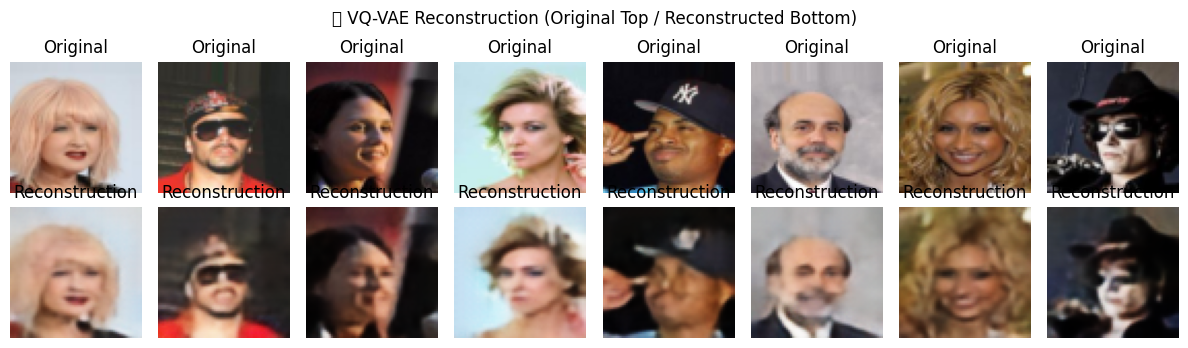

In [11]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# 🔁 Switch model to evaluation mode
model.eval()

# 🔍 Get one batch of images from the DataLoader
with torch.no_grad():
    for batch in celeba_loader:
        batch = batch.to(device)
        recon, _ = model(batch)
        break  # Only visualize the first batch

# 🧽 Unnormalize function (from [-1, 1] back to [0, 1])
def unnormalize(tensor):
    return (tensor + 1) / 2

# 🖼️ Plot original vs reconstructed
n = 8  # number of images to display

fig, axs = plt.subplots(2, n, figsize=(n * 1.5, 3.5))

for i in range(n):
    # Original
    axs[0, i].imshow(unnormalize(batch[i].detach().cpu()).permute(1, 2, 0))
    axs[0, i].set_title("Original")
    axs[0, i].axis('off')

    # Reconstructed
    axs[1, i].imshow(unnormalize(recon[i].detach().cpu()).permute(1, 2, 0))
    axs[1, i].set_title("Reconstruction")
    axs[1, i].axis('off')

plt.suptitle("🧠 VQ-VAE Reconstruction (Original Top / Reconstructed Bottom)")
plt.tight_layout()
plt.show()


🎯 Part 1: Visualizing the Latent Space Usage (Codebook Indices)
The idea: for a given batch of images, we want to see which codebook entries are being used.

This helps answer:

Is the codebook fully utilized or underused?

Are some embeddings never selected?



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


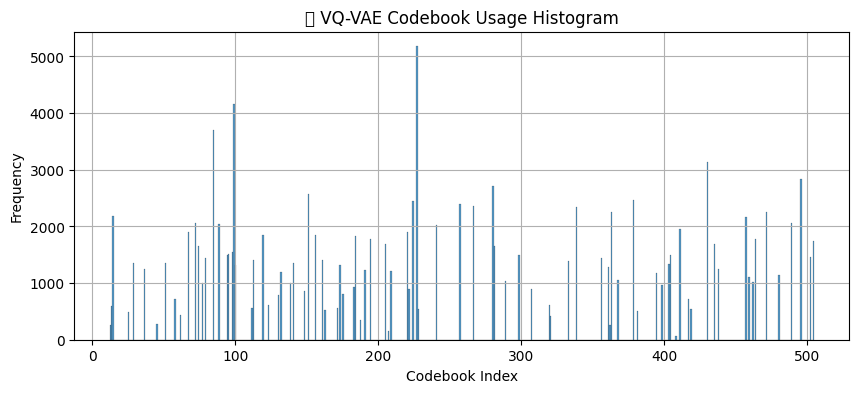

In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 👀 Function to extract codebook indices from the VQ-VAE model
def get_codebook_indices(model, dataloader, num_batches=5):
    model.eval()
    all_indices = []

    with torch.no_grad():
        for i, images in enumerate(dataloader):
            if i >= num_batches:
                break
            images = images.to(device)

            # Pass images through the encoder and the conv layer to get to the embedding space
            z = model.encoder(images)
            z = model.conv_to_embedding(z)  # Shape: [B, D, H, W]

            # Convert latent tensor shape from [B, D, H, W] to [B, H, W, D] for processing
            z_perm = z.permute(0, 2, 3, 1).contiguous()  # Now shape: [B, H, W, D]
            flat_z = z_perm.view(-1, z_perm.shape[-1])     # Flatten to shape: [BHW, D]

            # Calculate the L2 distance between each latent vector and the codebook embeddings
            distances = (
                torch.sum(flat_z ** 2, dim=1, keepdim=True) +   # ||z||^2
                torch.sum(model.vq_layer.embedding.weight ** 2, dim=1) -  # ||e||^2
                2 * torch.matmul(flat_z, model.vq_layer.embedding.weight.t())  # -2·zᵀe
            )

            # Get the index of the closest embedding for each latent vector
            indices = torch.argmin(distances, dim=1)
            all_indices.extend(indices.cpu().numpy())

    return np.array(all_indices)

# 🔍 Run on a few batches to extract codebook indices
codebook_indices = get_codebook_indices(model, celeba_loader, num_batches=10)

# 📊 Plot a histogram of the used codebook indices
plt.figure(figsize=(10, 4))
sns.histplot(codebook_indices, bins=model.vq_layer.K)
plt.xlabel("Codebook Index")
plt.ylabel("Frequency")
plt.title("📦 VQ-VAE Codebook Usage Histogram")
plt.grid(True)
plt.show()


🧪 Part 2: Unconditional Generation with VQ-VAE
We’ll:

Sample random indices k ∈ {1, ..., K} for each spatial location.

Look up the embeddings e_k from the codebook.

Reshape into [B, D, H, W] format.



/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127922 (\N{GAME DIE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


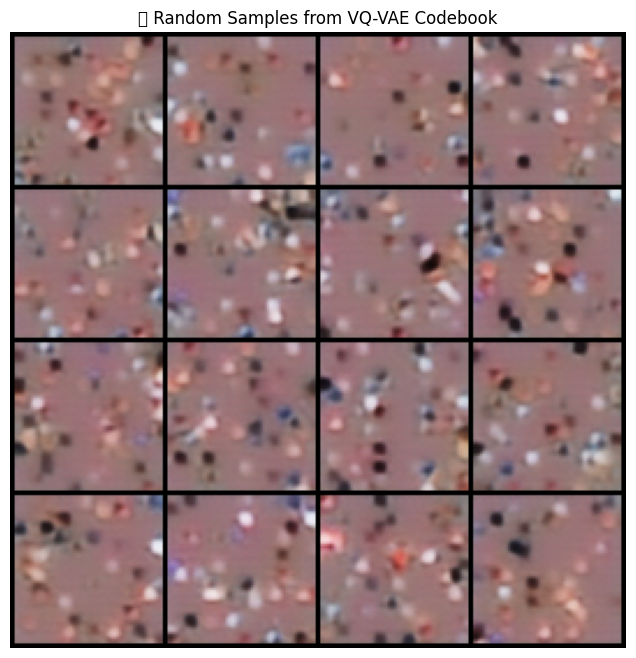

In [15]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torchvision.utils as vutils

def generate_from_codebook(model, grid_size=(4, 4)):
    """
    Generates random images by sampling codebook indices and decoding them using the trained VQ-VAE decoder.

    Args:
        model: Trained VQVAE model.
        grid_size: Tuple (rows, cols) specifying how many images to generate.

    Returns:
        generated_images: A tensor of generated images (unnormalized to [0,1]).
    """
    # Set model to evaluation mode
    model.eval()

    # Access the codebook parameters from the vector quantization layer
    # (Note: our VQ-VAE stores the quantizer as `vq_layer`)
    K = model.vq_layer.K        # Number of codebook entries
    D = model.vq_layer.D        # Embedding dimensionality
    device = next(model.parameters()).device

    # Determine the spatial dimensions of the latent feature map produced by the encoder:
    # Pass a dummy input image through the encoder and conv-to-embedding layer.
    dummy_input = torch.randn(1, 3, 64, 64).to(device)
    with torch.no_grad():
        z = model.encoder(dummy_input)
        z = model.conv_to_embedding(z)  # Shape: [B, D, H, W]
    _, _, H, W = z.shape

    # Calculate total number of images to generate from the grid
    B = grid_size[0] * grid_size[1]  # Total images = rows * columns

    # 🎲 Sample random codebook indices for each spatial position in the latent feature map
    # Shape: [B, H, W] with values in [0, K-1]
    random_indices = torch.randint(0, K, (B, H, W), device=device)

    # Lookup the corresponding embeddings for each index:
    # Get the codebook embedding weights: shape [K, D]
    embeddings = model.vq_layer.embedding.weight  # [K, D]
    # Index into the embeddings using our random indices:
    # Resulting shape: [B, H, W, D]
    sampled = embeddings[random_indices]

    # Rearrange the sampled embeddings to match the decoder's expected input shape:
    # From [B, H, W, D] to [B, D, H, W]
    sampled = sampled.permute(0, 3, 1, 2).contiguous()

    # Map the embedding space back to the hidden channel dimension for the decoder.
    # Note: In our implementation, this layer is called `embedding_to_decoder`
    z_dec = model.embedding_to_decoder(sampled)

    # Decode the latent representation into images using the VQ-VAE decoder.
    with torch.no_grad():
        generated_images = model.decoder(z_dec)

    # Unnormalize the output images from the range [-1, 1] to [0, 1]
    generated_images = (generated_images + 1) / 2

    return generated_images.cpu()

# Generate images from the codebook using the model and plot them:
generated = generate_from_codebook(model, grid_size=(4, 4))

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("🎲 Random Samples from VQ-VAE Codebook")
# Permute generated images to H x W x C for visualization and use make_grid for a grid layout.
grid_img = vutils.make_grid(generated, nrow=4).permute(1, 2, 0)
plt.imshow(grid_img)
plt.show()


🔁 VQ-VAE Latent Interpolation
We’ll:

Take two real input images x₁ and x₂.

Encode both to their quantized latent spaces: z_q(x₁) and z_q(x₂).

Interpolate between these quantized latents.

Decode each interpolated latent to generate an image.

Visualize the resulting morphing.

⚠️ Important Note:
In VQ-VAE, interpolation is non-trivial because latent codes are discrete (index-based).
So we interpolate between the quantized embeddings (not the indices), or between pre-quantized vectors and then quantize them.

We'll go with interpolating between the quantized embeddings for clarity.

In [17]:
def interpolate_latents(model, image1, image2, steps=8):
    """
    Interpolates between two input images in latent space.

    Args:
        model: Trained VQ-VAE model
        image1, image2: Tensors [C, H, W] normalized to [-1, 1]
        steps: Number of interpolation steps

    Returns:
        Tensor of interpolated decoded images [steps, C, H, W]
    """
    model.eval()
    with torch.no_grad():
        image1 = image1.unsqueeze(0).to(device)
        image2 = image2.unsqueeze(0).to(device)

        # Step 1: Encode and quantize both images
        z1 = model.encoder(image1)
        z1 = model.conv_to_embedding(z1)
        zq1, _ = model.quantizer(z1)

        z2 = model.encoder(image2)
        z2 = model.conv_to_embedding(z2)
        zq2, _ = model.quantizer(z2)

        # Step 2: Interpolate linearly between the quantized latents
        interpolated_latents = []
        for alpha in torch.linspace(0, 1, steps):
            z_interp = (1 - alpha) * zq1 + alpha * zq2
            interpolated_latents.append(z_interp)

        # Step 3: Decode all interpolated latents
        outputs = []
        for z in interpolated_latents:
            z_dec = model.embedding_to_conv(z)
            recon = model.decoder(z_dec)
            outputs.append(recon.squeeze(0))  # remove batch dim

        # Step 4: Stack and unnormalize for visualization
        interpolated_images = torch.stack(outputs)
        interpolated_images = (interpolated_images + 1) / 2  # [-1, 1] → [0, 1]
        return interpolated_images.cpu()


🔍 Visualize the Interpolation

In [22]:
# 🖼️ Select two samples from the dataset.
# We assume that 'celeba_dataset' returns a tuple (image, label) and we only need the image.
# Adjust indices as needed.
img1 = celeba_dataset[10]
img2= celeba_dataset[130]

# Add a batch dimension (if your model expects a 4D tensor: [B, C, H, W])
img1 = img1.unsqueeze(0)
img2 = img2.unsqueeze(0)

# Move images to the same device as your model (e.g., 'cuda' or 'cpu')
img1 = img1.to(device)
img2 = img2.to(device)

# 🎨 Generate interpolated images in the latent space.
# The function 'interpolate_latents' should:
#   1. Encode img1 and img2 to obtain their latent representations.
#   2. Perform linear interpolation between the two latent vectors across a specified number of steps.
#   3. Decode each interpolated latent back into an image.
# Here we use 8 interpolation steps.
interpolated = interpolate_latents(model, img1, img2, steps=8)

# 📊 Visualize the results.
# We will create a grid to display all interpolated images side-by-side.
import matplotlib.pyplot as plt

# Create a subplot with 1 row and 8 columns
fig, axs = plt.subplots(1, 8, figsize=(16, 2))

# Loop over the interpolated images and display each
for i in range(8):
    # The output is assumed to be in tensor format with shape [C, H, W].
    # We use .permute(1, 2, 0) to convert it to [H, W, C] for matplotlib.
    axs[i].imshow(interpolated[i].permute(1, 2, 0).cpu().numpy())
    axs[i].axis('off')
    axs[i].set_title(f"Step {i+1}")

plt.suptitle("VQ-VAE Latent Space Interpolation")
plt.show()


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [1, 1, 3, 64, 64]